# **Hands-on Exercise: Decision Trees & Customer Segmentation**
**General Instruction:** Read and study Section 6.2 of your Data Mining reference book and work on the Business Case below.

# **Business Case: "Project Wrist-Tech"**
**Scenario:** OmniGear, a mid-sized consumer electronics retailer, is launching a highly targeted marketing campaign for a new, premium smartwatch. Sending promotional kits (catalogs, discount codes, and free interchangeable bands) to every customer is too expensive.

**Objective:** The marketing team needs your help to build a Decision Tree model to predict whether an existing customer will purchase the new smartwatch based on their profile. This will allow the team to extract clear "Business Rules" to identify the exact customer segments they should target.


In [1]:
# Import the necessary libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


# The **Dataset**

In [2]:
data = {
    'Customer ID': ['C001', 'C002', 'C003', 'C004', 'C005', 'C006', 'C007',
                    'C008', 'C009', 'C010', 'C011', 'C012', 'C013', 'C014',
                    'C015', 'C016', 'C017', 'C018', 'C019', 'C020', 'C021',
                    'C022', 'C023', 'C024', 'C025', 'C026', 'C027', 'C028',
                    'C029', 'C030'],
    'Age Group': ['Youth', 'Youth', 'Adult', 'Senior', 'Senior', 'Senior', 'Adult',
                  'Youth', 'Youth', 'Senior', 'Youth', 'Adult', 'Adult', 'Senior',
                  'Adult', 'Youth', 'Senior', 'Youth', 'Adult', 'Senior', 'Youth',
                  'Adult', 'Youth', 'Senior', 'Adult', 'Youth', 'Adult', 'Senior',
                  'Youth', 'Adult'],
    'Income Level': ['High', 'High', 'High', 'Medium', 'Low', 'Low', 'Low',
                     'Medium', 'Low', 'Medium', 'Medium', 'Medium', 'High', 'Medium',
                     'High', 'Low', 'Medium', 'High', 'Low', 'Medium', 'Medium',
                     'High', 'Low', 'Medium', 'Medium', 'High', 'Low', 'Medium',
                     'High', 'Low'],
    'Tech Savvy': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal',
                   'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High',
                   'High', 'Normal', 'High', 'Normal', 'High', 'Normal', 'Normal',
                   'High', 'Normal', 'High', 'High', 'Normal', 'High', 'Normal',
                   'High', 'Normal'],
    'Fitness App User': ['No', 'Yes', 'No', 'No', 'No', 'Yes', 'Yes',
                         'No', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes',
                         'Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'Yes',
                         'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No',
                         'Yes', 'No'],
    'Buys Smartwatch': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
                        'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No',
                        'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes',
                        'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes',
                        'No', 'Yes']
}

# Load into a Pandas DataFrame
df = pd.DataFrame(data)

# Display the first few rows to verify
display(df.head())

,Customer ID,Age Group,Income Level,Tech Savvy,Fitness App User,Buys Smartwatch
0,C001,Youth,High,High,No,No
1,C002,Youth,High,High,Yes,No
2,C003,Adult,High,High,No,Yes
3,C004,Senior,Medium,High,No,Yes
4,C005,Senior,Low,Normal,No,Yes


# **Visualizing Customer Segments**

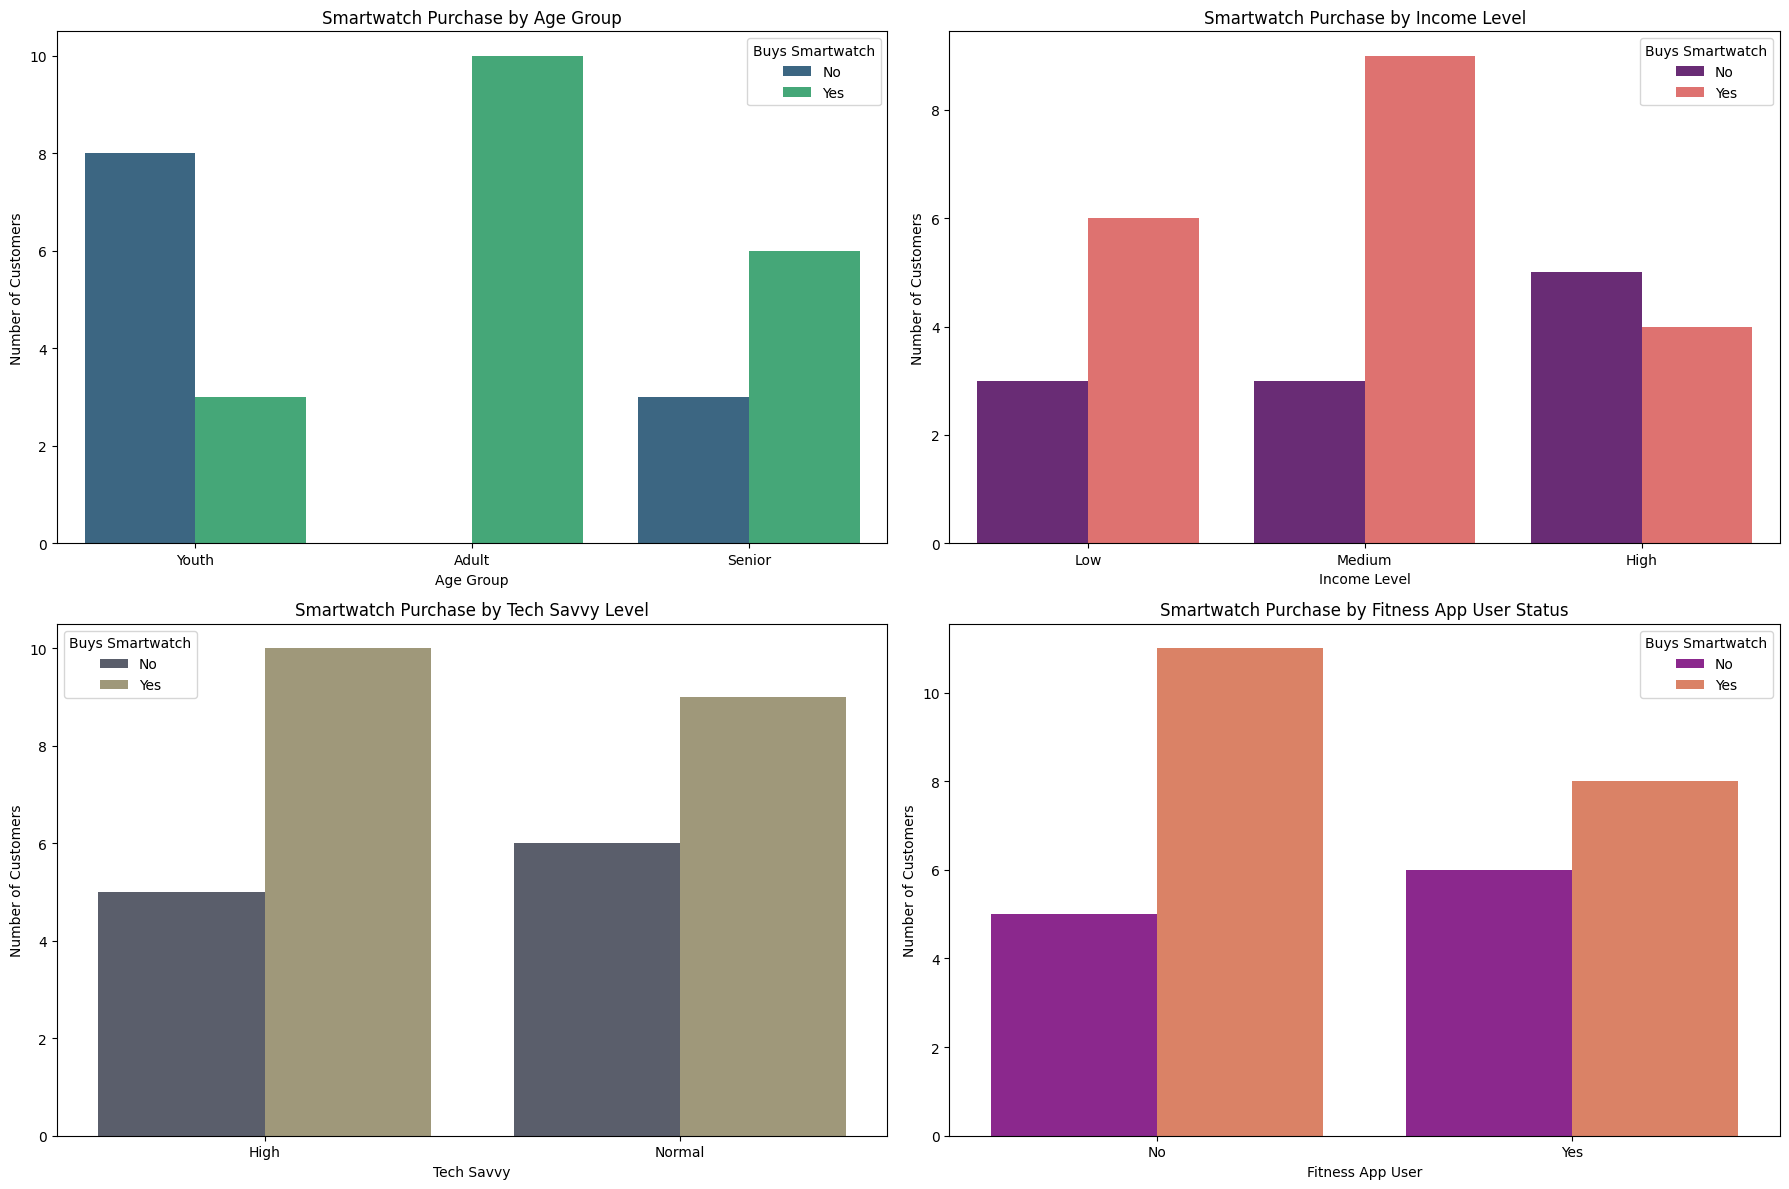

In [3]:
import seaborn as sns

plt.figure(figsize=(18, 12))

# Plot Age Group distribution with Buys Smartwatch
plt.subplot(2, 2, 1) # 2 rows, 2 columns, 1st plot
sns.countplot(data=df, x='Age Group', hue='Buys Smartwatch', palette='viridis')
plt.title('Smartwatch Purchase by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

# Plot Income Level distribution with Buys Smartwatch
plt.subplot(2, 2, 2) # 2 rows, 2 columns, 2nd plot
sns.countplot(data=df, x='Income Level', hue='Buys Smartwatch', palette='magma', order=['Low', 'Medium', 'High'])
plt.title('Smartwatch Purchase by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Number of Customers')

# Plot Tech Savvy distribution with Buys Smartwatch
plt.subplot(2, 2, 3) # 2 rows, 2 columns, 3rd plot
sns.countplot(data=df, x='Tech Savvy', hue='Buys Smartwatch', palette='cividis')
plt.title('Smartwatch Purchase by Tech Savvy Level')
plt.xlabel('Tech Savvy')
plt.ylabel('Number of Customers')

# Plot Fitness App User distribution with Buys Smartwatch
plt.subplot(2, 2, 4) # 2 rows, 2 columns, 4th plot
sns.countplot(data=df, x='Fitness App User', hue='Buys Smartwatch', palette='plasma')
plt.title('Smartwatch Purchase by Fitness App User Status')
plt.xlabel('Fitness App User')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

# **Simple Preprocessing and One-hot Encoding**

In [4]:
# Separate the features (X) from the target (y)
# We drop Customer ID because it is just an identifier, not a predictor
X_raw = df.drop(columns=['Customer ID', 'Buys Smartwatch'])
y = df['Buys Smartwatch']

# Use pandas get_dummies to convert categorical text data into binary (1/0) columns
X = pd.get_dummies(X_raw)

print("Transformed Feature Set (First 3 rows):")
display(X.head(3))

Transformed Feature Set (First 3 rows):


,Age Group_Adult,Age Group_Senior,Age Group_Youth,Income Level_High,Income Level_Low,Income Level_Medium,Tech Savvy_High,Tech Savvy_Normal,Fitness App User_No,Fitness App User_Yes
0,False,False,True,True,False,False,True,False,True,False
1,False,False,True,True,False,False,True,False,False,True
2,True,False,False,True,False,False,True,False,True,False


### **Entropy Calculation**

**Entropy** is a measure of impurity or randomness in a set of data. In the context of a decision tree, it quantifies the uncertainty in the target variable within a node. An entropy of 0 means the node is perfectly pure (all samples belong to the same class), while an entropy of 1 (for a binary classification) means the node is perfectly impure (samples are evenly split between classes).

The formula for entropy (H) for a binary classification problem is:

$H(S) = -P(Yes) \log_2 P(Yes) - P(No) \log_2 P(No)$

Where:
- $S$ is the set of samples.
- $P(Yes)$ is the proportion of 'Yes' instances in the set.
- $P(No)$ is the proportion of 'No' instances in the set.


In [5]:
import numpy as np

def entropy_calc(target_column):
    """
    Calculates the entropy of a categorical column.
    """
    value_counts = target_column.value_counts()
    probabilities = value_counts / len(target_column)
    # Handle cases where probability is 0 to avoid log2(0)
    probabilities = probabilities[probabilities > 0]
    entropy = -np.sum(probabilities * np.log2(probabilities))
    return entropy

# Calculate the overall entropy of the 'Buys Smartwatch' column
overall_entropy = entropy_calc(df['Buys Smartwatch'])
print(f"Overall Entropy of 'Buys Smartwatch' (Parent Node): {overall_entropy:.4f}")

Overall Entropy of 'Buys Smartwatch' (Parent Node): 0.9481


# **Exercise Question:**

In our dataset, the "Adult" branch of the Age Group feature resulted in an entropy of exactly 0. What does an entropy of 0 represent, and why is this the ideal outcome for a targeted marketing campaign?

### **Information Gain Calculation**

**Information Gain** measures the reduction in entropy (or uncertainty) after splitting a dataset based on a particular feature. A higher information gain indicates a better split, as it means the feature provides more information about the target variable.

The formula for Information Gain (IG) for a feature (A) is:

$IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)$

Where:
- $H(S)$ is the entropy of the parent node (before the split).
- $Values(A)$ are the possible values for attribute $A$.
- $S_v$ is the subset of $S$ for which attribute $A$ has value $v$.
- $|S_v|$ is the number of elements in $S_v$.
- $|S|$ is the total number of elements in $S$.
- $H(S_v)$ is the entropy of the subset $S_v$.

Let's calculate the Information Gain for each of our original features.

In [6]:
print("\nInformation Gain for each feature (original, non-one-hot encoded features):\n")

# Recalculate overall entropy for clarity
overall_entropy = entropy_calc(df['Buys Smartwatch'])

# Iterate through each feature in the raw feature set (before one-hot encoding)
for feature in X_raw.columns:
    weighted_avg_entropy = 0
    # Get unique values for the current feature
    unique_values = df[feature].unique()

    for value in unique_values:
        # Subset the DataFrame based on the current feature's value
        subset = df[df[feature] == value]
        # Calculate the proportion of this subset relative to the entire dataset
        proportion = len(subset) / len(df)
        # Calculate the entropy of the 'Buys Smartwatch' column within this subset
        subset_entropy = entropy_calc(subset['Buys Smartwatch'])
        # Add to the weighted average entropy
        weighted_avg_entropy += proportion * subset_entropy

    # Calculate Information Gain
    information_gain = overall_entropy - weighted_avg_entropy
    print(f"  Information Gain for '{feature}': {information_gain:.4f}")


Information Gain for each feature (original, non-one-hot encoded features):

  Information Gain for 'Age Group': 0.3626
  Information Gain for 'Income Level': 0.0508
  Information Gain for 'Tech Savvy': 0.0035
  Information Gain for 'Fitness App User': 0.0104


In [7]:
# Initialize the Decision Tree model
# We set random_state to ensure everyone gets the exact same tree structure
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Train (fit) the model using our data
clf.fit(X, y)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


## **Visualize the Tree and Extract Rules**

**How to read the tree:**
* **Entropy:** Shows the impurity of that specific node. (0.0 means it is perfectly pure!).
* **Samples:** How many customers made it to this point.
* **Value:** How many customers fall into the [No, Yes] categories at this node.
* **Class:** The predicted outcome for that node.

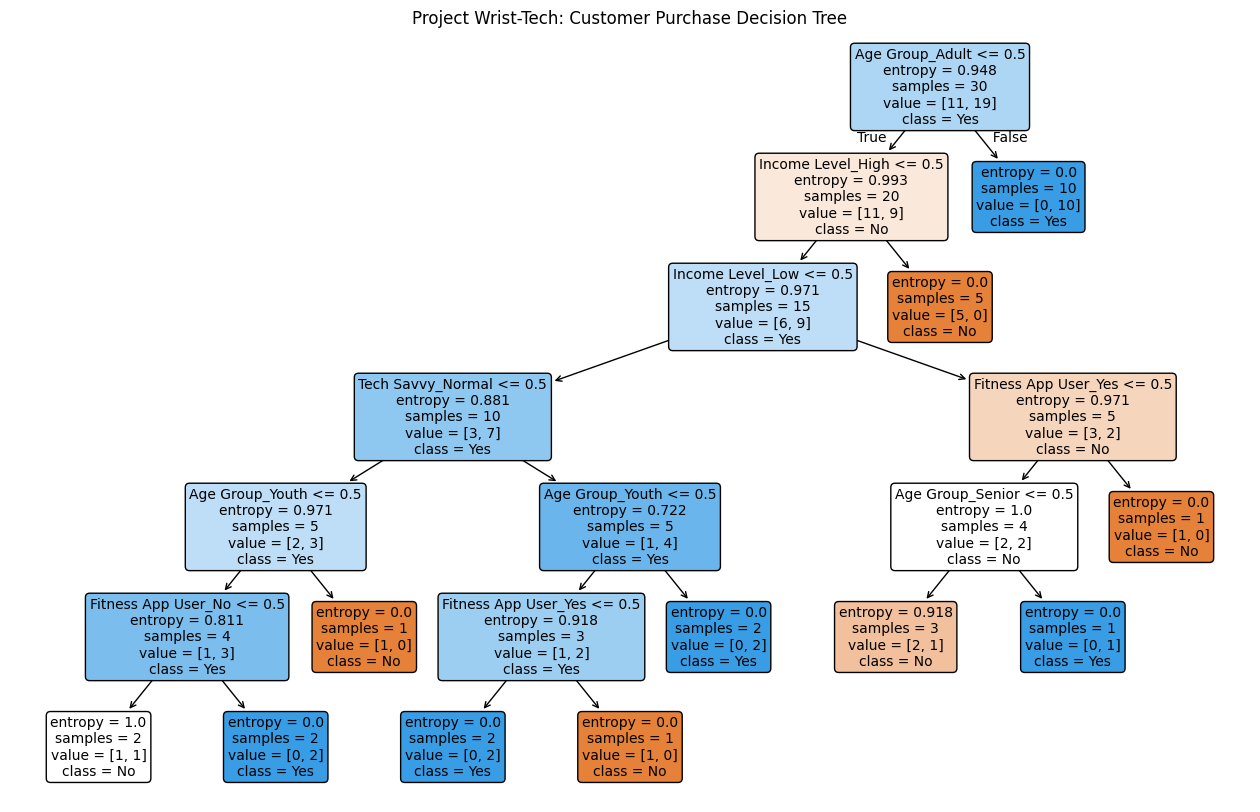

In [8]:
# Set up the plot size
plt.figure(figsize=(16, 10))

# Plot the tree
plot_tree(clf,
          feature_names=X.columns,
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True,
          fontsize=10)

# Display the plot
plt.title("Project Wrist-Tech: Customer Purchase Decision Tree")
plt.show()

# **Exercise Question:**

Decision trees are described as "greedy" algorithms because they make the best local split at each node without looking ahead. Based on the Project Wrist-Tech tree, can you identify a potential downside to this greedy approach when applying the model to thousands of diverse customers?

# **Extract and Print Decision Rules**
We can also extract the decision rules in a text-based format, which can be useful for understanding the model's logic without looking at the visual tree.


In [9]:
from sklearn.tree import export_text

# Get the text representation of the decision tree
tree_rules = export_text(clf, feature_names=list(X.columns), class_names=['No', 'Yes'])

# Print the rules
print("Decision Tree Rules:\n")
print(tree_rules)

Decision Tree Rules:

|--- Age Group_Adult <= 0.50
|   |--- Income Level_High <= 0.50
|   |   |--- Income Level_Low <= 0.50
|   |   |   |--- Tech Savvy_Normal <= 0.50
|   |   |   |   |--- Age Group_Youth <= 0.50
|   |   |   |   |   |--- Fitness App User_No <= 0.50
|   |   |   |   |   |   |--- class: No
|   |   |   |   |   |--- Fitness App User_No >  0.50
|   |   |   |   |   |   |--- class: Yes
|   |   |   |   |--- Age Group_Youth >  0.50
|   |   |   |   |   |--- class: No
|   |   |   |--- Tech Savvy_Normal >  0.50
|   |   |   |   |--- Age Group_Youth <= 0.50
|   |   |   |   |   |--- Fitness App User_Yes <= 0.50
|   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |--- Fitness App User_Yes >  0.50
|   |   |   |   |   |   |--- class: No
|   |   |   |   |--- Age Group_Youth >  0.50
|   |   |   |   |   |--- class: Yes
|   |   |--- Income Level_Low >  0.50
|   |   |   |--- Fitness App User_Yes <= 0.50
|   |   |   |   |--- Age Group_Senior <= 0.50
|   |   |   |   |   |--- class: No
| 

---
# **Categorical Plot**
While the Decision Tree diagram shows us the *rules*, visualizing the actual data points helps us see the *segments*. Let's plot our customers based on our most important primary rule (`Age Group`) and our most predictive secondary rule (`Tech Savvy`).

**Business Takeaways from this Plot:**
1. **The Pure Node:** Look at the `Adult` column. Notice how every single dot is Green (Yes). This visually proves why the Adult branch hit an Entropy of 0 in the tree above—there is no uncertainty.
2. **The Need for Secondary Rules:** Look at the `Youth` column. It is a mix of Red and Green dots, meaning `Age` alone isn't enough to predict their behavior. However, notice how the colors are grouped: Red dots cluster at `High` Tech Savvy, and Green dots cluster at `Normal`. This visually proves why the Decision Tree needed to ask about Tech Savviness to accurately split the Youth demographic!

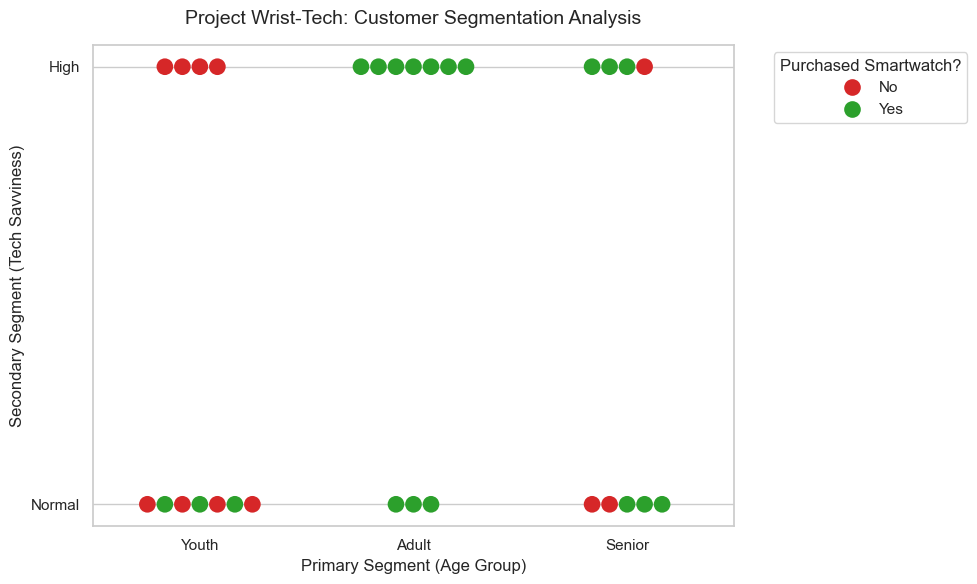

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create a categorical plot (swarm plot works well for small datasets)
# We plot Age Group on the X-axis, Tech Savvy on the Y-axis, and color by Purchase
ax = sns.swarmplot(
    data=df,
    x="Age Group",
    y="Tech Savvy",
    hue="Buys Smartwatch",
    palette={"Yes": "#2ca02c", "No": "#d62728"}, # Green for Yes, Red for No
    size=12,
    marker="o"
)

# Customize the chart for the Marketing Team
plt.title("Project Wrist-Tech: Customer Segmentation Analysis", fontsize=14, pad=15)
plt.xlabel("Primary Segment (Age Group)", fontsize=12)
plt.ylabel("Secondary Segment (Tech Savviness)", fontsize=12)
plt.legend(title="Purchased Smartwatch?", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# **Visualizing the Tree Logic (Sunburst Chart)**
Finally, we can visualize the hierarchical "If-Then" logic of our Decision Tree using a Sunburst Chart. It is essentially a Decision Tree curled up into a circle, showing how the total population of customers breaks down as we apply more specific business rules.

**How to read the Sunburst Chart:**
* **The Rings:** Start from the center and read outward. The innermost circle is the Root Node (`Age Group`). The middle ring is the second question (`Tech Savvy`). The outermost edge is the final prediction (`Yes/No`).
* **Tracing a Business Rule:** Trace the path for highly tech-savvy youths. Click `Youth` (inner ring) $\rightarrow$ `High` (middle ring) $\rightarrow$ and you will see the outer edge is entirely Red (`No`).
* **Interactive Slices:** The physical size of the slices represents the number of customers in that segment. You can click on any inner slice to zoom in and explore that specific demographic branch.

In [11]:
import plotly.express as px

# To make a sunburst, we first need to group our data by the hierarchical paths
# Path: Age Group -> Tech Savvy -> Buys Smartwatch
df_sunburst = df.groupby(['Age Group', 'Tech Savvy', 'Buys Smartwatch']).size().reset_index(name='Count')

# Generate the Sunburst Chart
fig = px.sunburst(
    df_sunburst,
    path=['Age Group', 'Tech Savvy', 'Buys Smartwatch'],
    values='Count',
    title='Project Wrist-Tech: Customer Segmentation Hierarchy',
    color='Buys Smartwatch',
    color_discrete_map={'Yes': '#2ca02c', 'No': '#d62728'} # Green for Yes, Red for No
)

# Enlarge the chart for readability
fig.update_layout(width=800, height=800)

# Display the interactive chart
fig.show()